In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [ ]:

# column names
# id = engine unit number
# cycle = time in cycles
# op1, op2, op3 = 3 operational settings
# s1-s21 = 21 sensor readings

columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

#FD001 training data
train = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=columns)

print(train.shape)
print(train.head())

In [2]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op1        20631 non-null  float64
 3   op2        20631 non-null  float64
 4   op3        20631 non-null  float64
 5   s1         20631 non-null  float64
 6   s2         20631 non-null  float64
 7   s3         20631 non-null  float64
 8   s4         20631 non-null  float64
 9   s5         20631 non-null  float64
 10  s6         20631 non-null  float64
 11  s7         20631 non-null  float64
 12  s8         20631 non-null  float64
 13  s9         20631 non-null  float64
 14  s10        20631 non-null  float64
 15  s11        20631 non-null  float64
 16  s12        20631 non-null  float64
 17  s13        20631 non-null  float64
 18  s14        20631 non-null  float64
 19  s15        20631 non-null  float64
 20  s16   

In [3]:
train.isnull().sum()

engine_id    0
cycle        0
op1          0
op2          0
op3          0
s1           0
s2           0
s3           0
s4           0
s5           0
s6           0
s7           0
s8           0
s9           0
s10          0
s11          0
s12          0
s13          0
s14          0
s15          0
s16          0
s17          0
s18          0
s19          0
s20          0
s21          0
dtype: int64

In [4]:
print("Number of engines:", train['engine_id'].nunique())
print("Max cycles per engine:\n", train.groupby('engine_id')['cycle'].max().describe())

Number of engines: 100
Max cycles per engine:
 count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [5]:
engine_1 = train[train['engine_id'] == 1]

print("Engine 1 total cycles:", engine_1['cycle'].max())
print("First 3 rows:\n", engine_1.head(3))
print("Last 3 rows:\n", engine_1.tail(3))

Engine 1 total cycles: 192
First 3 rows:
    engine_id  cycle     op1     op2    op3      s1      s2       s3       s4  \
0          1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1          1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2          1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  38.95  23.3442  

[3 rows x 26 columns]
Last 3 rows:
      engine_id  cycle     op1     op2    op3      s1      s2       s3  \
189          1    190 -0.0027  0.0001  100.0  518.67  643.64  1599.22   
190          1    191 -0.0000 -0.0004  100.0  518.67  643.34  1602.36   


In [6]:
# Calculate max cycle per engine (The cycle it failed at)
max_cycles = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

#Merge back and caluculate RUL(Remaining Useful Life)
train = train.merge(max_cycles, on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle'] 



In [7]:
train

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,200,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,200,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,200,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,200,1


In [8]:
#Dropping max_cycle column, we dont need it 
train.drop(columns =['max_cycle'], inplace = True)

In [9]:
print(train[['engine_id', 'cycle', 'RUL']].head(10))
print("\nRUL at last cycle of engine 1:", train[train['engine_id']==1]['RUL'].min())

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187
5          1      6  186
6          1      7  185
7          1      8  184
8          1      9  183
9          1     10  182

RUL at last cycle of engine 1: 0


In [10]:
print(train.shape)
print(train[['engine_id', 'cycle', 'RUL']].tail(5))

(20631, 27)
       engine_id  cycle  RUL
20626        100    196    4
20627        100    197    3
20628        100    198    2
20629        100    199    1
20630        100    200    0


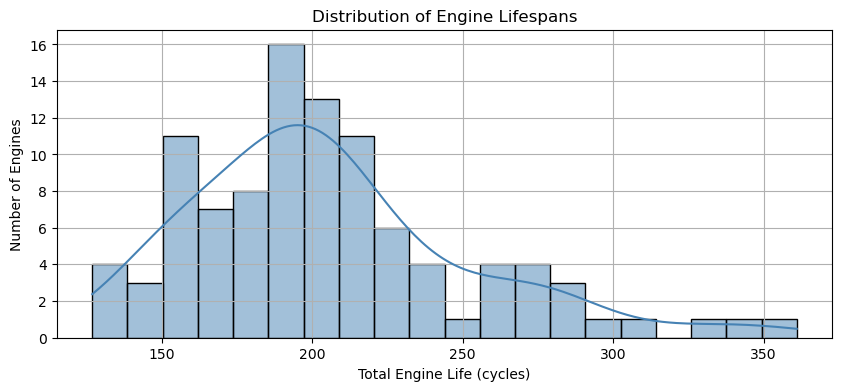

Average engine lifespan: 205.3
Shortest life: 127
Longest life: 361


In [12]:


# the max RUL per engine (= total life of each engine)
rul_dist = train.groupby('engine_id')['RUL'].max()

plt.figure(figsize=(10, 4))
sns.histplot(rul_dist, bins=20, kde=True, color='steelblue')
plt.xlabel('Total Engine Life (cycles)')
plt.ylabel('Number of Engines')
plt.title('Distribution of Engine Lifespans')
plt.grid(True)
plt.show()

print("Average engine lifespan:", rul_dist.mean().round(1))
print("Shortest life:", rul_dist.min())
print("Longest life:", rul_dist.max())

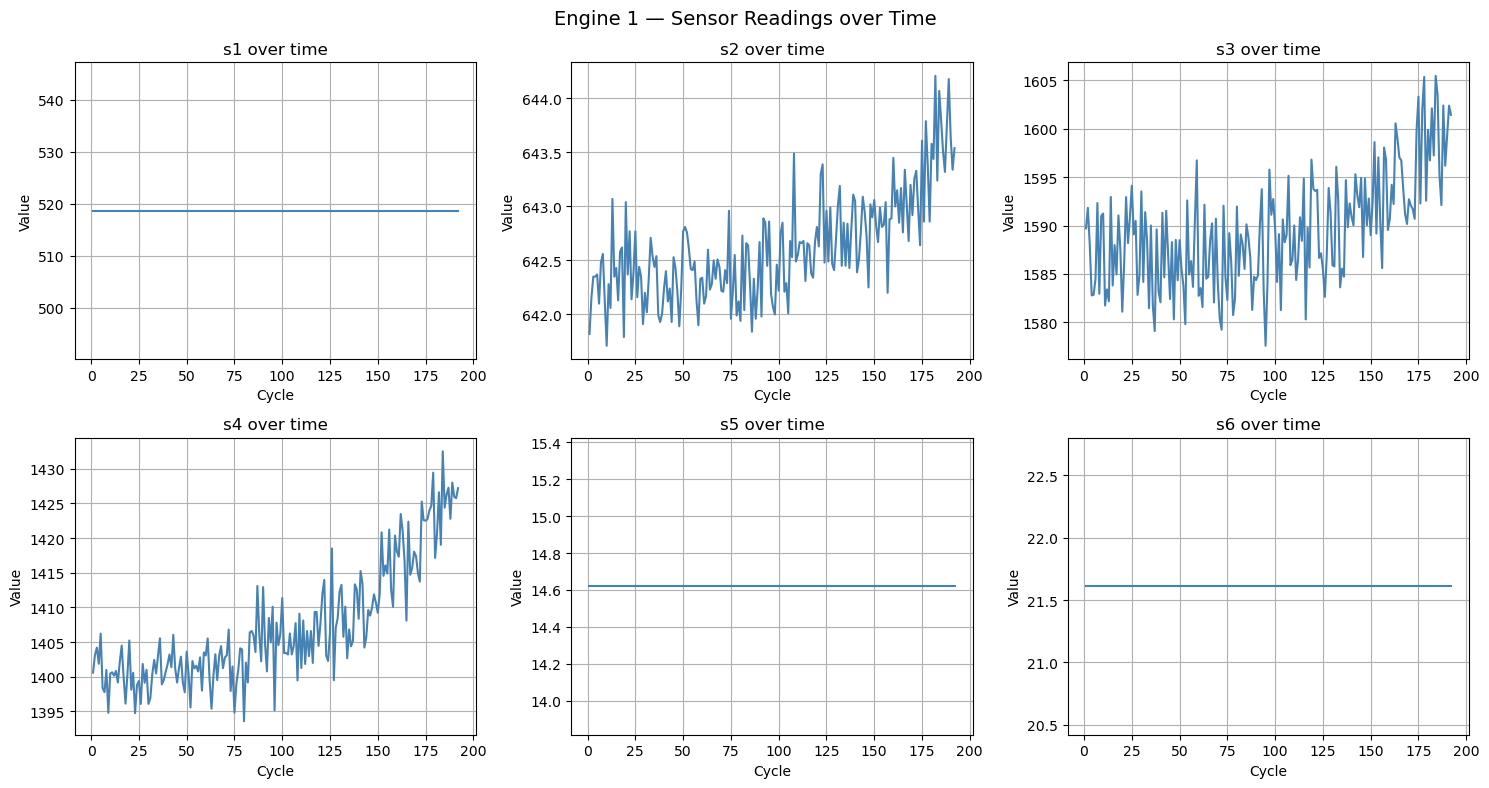

In [13]:
# Plotting first 6 sensors for engine 1 to see their behavior over time
engine_1 = train[train['engine_id'] == 1]
sensors_to_plot = ['s1', 's2', 's3', 's4', 's5', 's6']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    axes[i].plot(engine_1['cycle'], engine_1[sensor], color='steelblue')
    axes[i].set_title(f'{sensor} over time')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

plt.suptitle('Engine 1 — Sensor Readings over Time', fontsize=14)
plt.tight_layout()
plt.show()

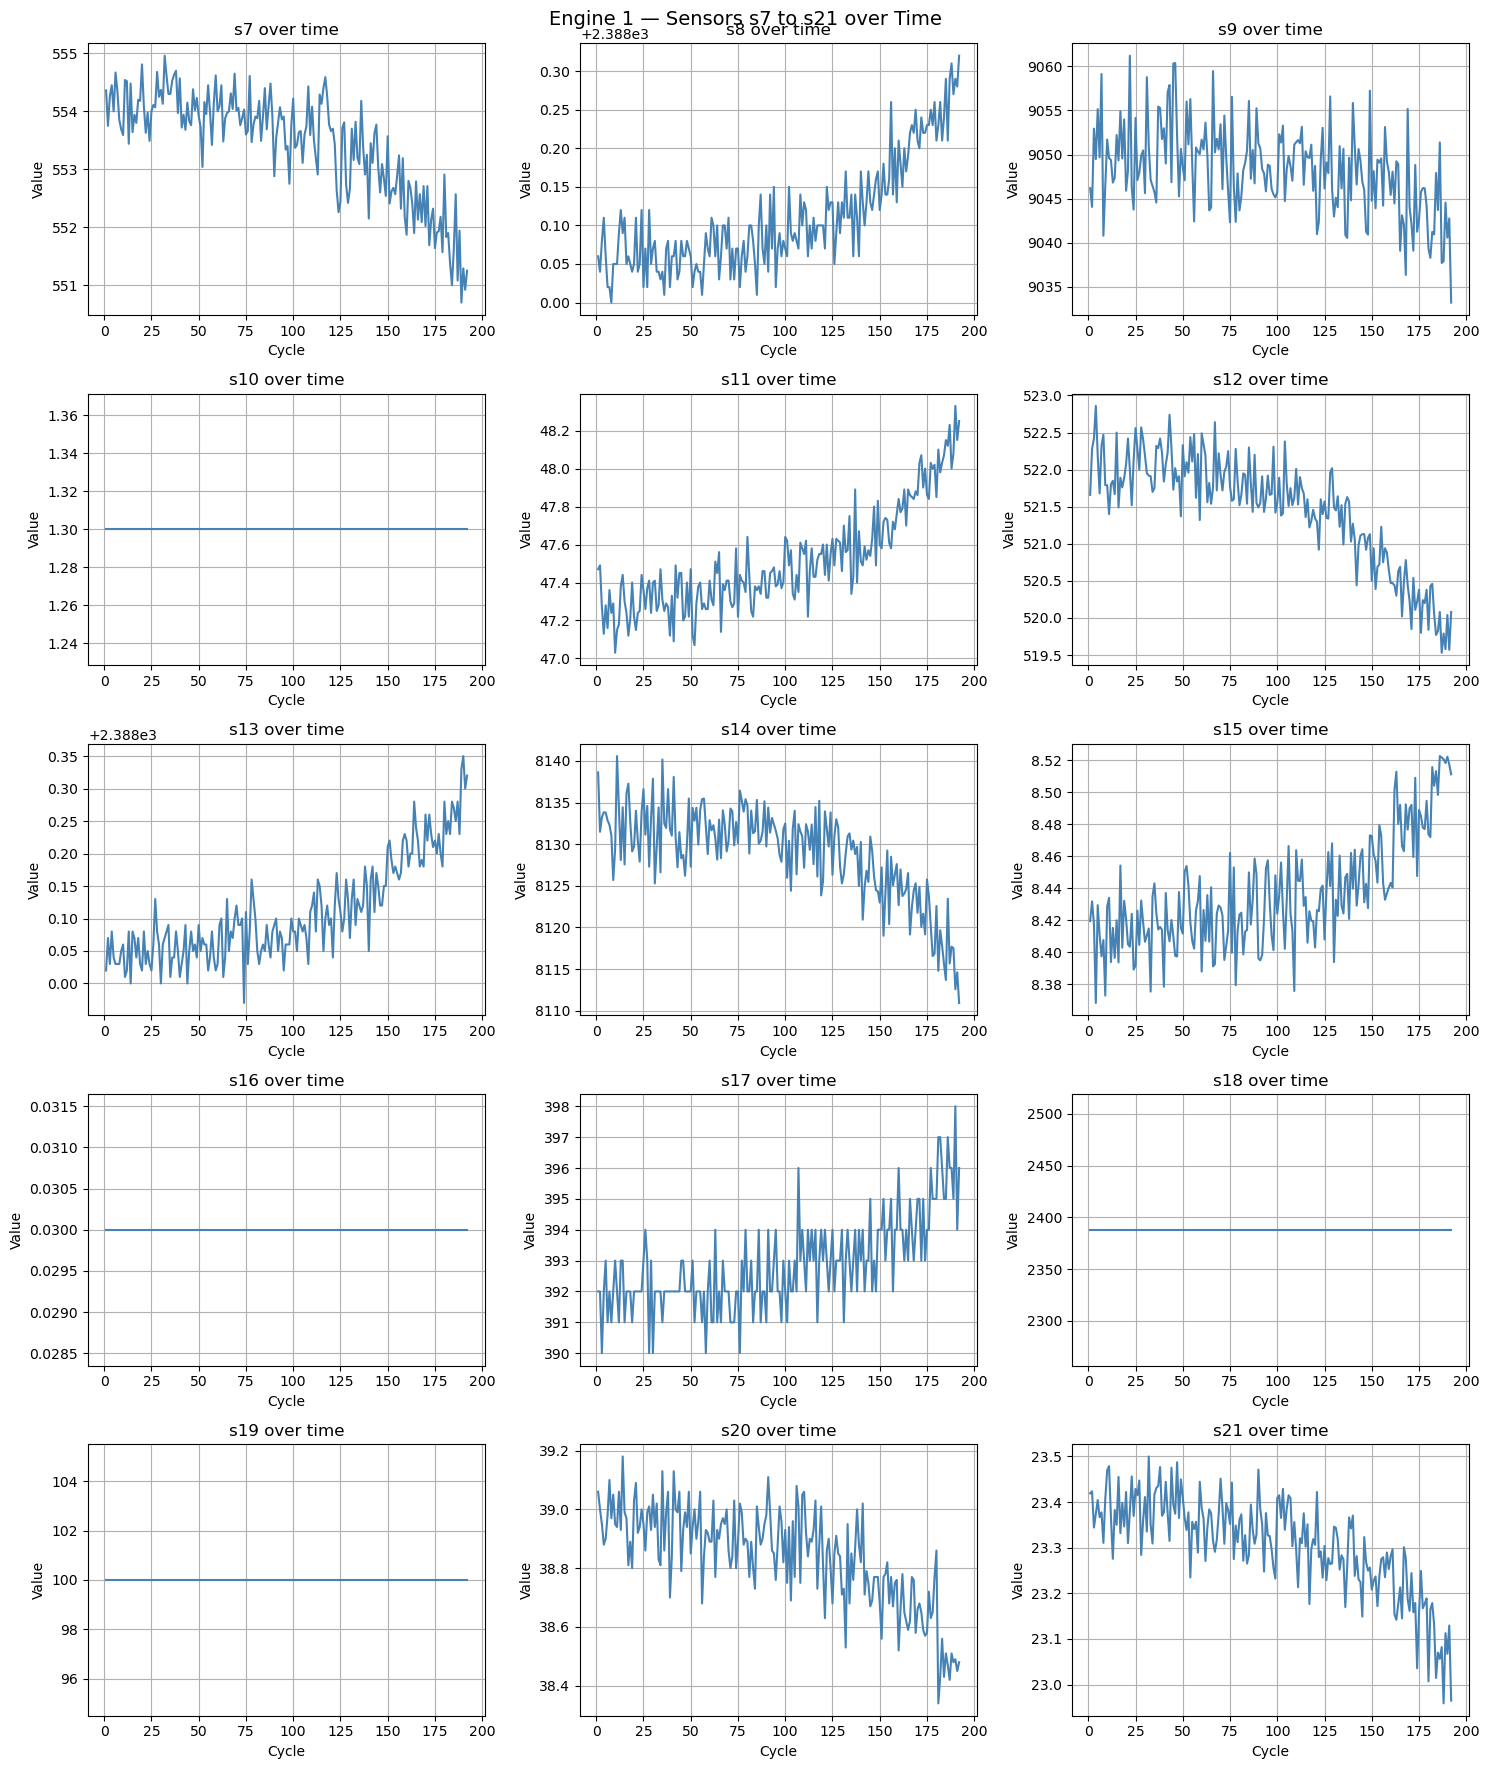

In [14]:
# Plotting all remaining sensors s7 to s21
sensors_to_plot = ['s7', 's8', 's9', 's10', 's11', 's12', 
                   's13', 's14', 's15', 's16', 's17', 's18', 
                   's19', 's20', 's21']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    axes[i].plot(engine_1['cycle'], engine_1[sensor], color='steelblue')
    axes[i].set_title(f'{sensor} over time')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

plt.suptitle('Engine 1 — Sensors s7 to s21 over Time', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Calculating std deviation of each sensor
# Flat sensors will have std close to 0

sensor_std = train[[f's{i}' for i in range(1, 22)]].std()

print("Sensor Standard Deviations:")
print(sensor_std.sort_values())

Sensor Standard Deviations:
s19    0.000000e+00
s18    0.000000e+00
s16    1.556432e-14
s10    4.660829e-13
s5     3.394700e-12
s1     6.537152e-11
s6     1.388985e-03
s15    3.750504e-02
s8     7.098548e-02
s13    7.191892e-02
s21    1.082509e-01
s20    1.807464e-01
s11    2.670874e-01
s2     5.000533e-01
s12    7.375534e-01
s7     8.850923e-01
s17    1.548763e+00
s3     6.131150e+00
s4     9.000605e+00
s14    1.907618e+01
s9     2.208288e+01
dtype: float64


In [16]:
# These sensors are flat and carry no useful information
flat_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

print("Sensors to drop:", flat_sensors)
print("Sensors to keep:", [s for s in [f's{i}' for i in range(1,22)] if s not in flat_sensors])

Sensors to drop: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Sensors to keep: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


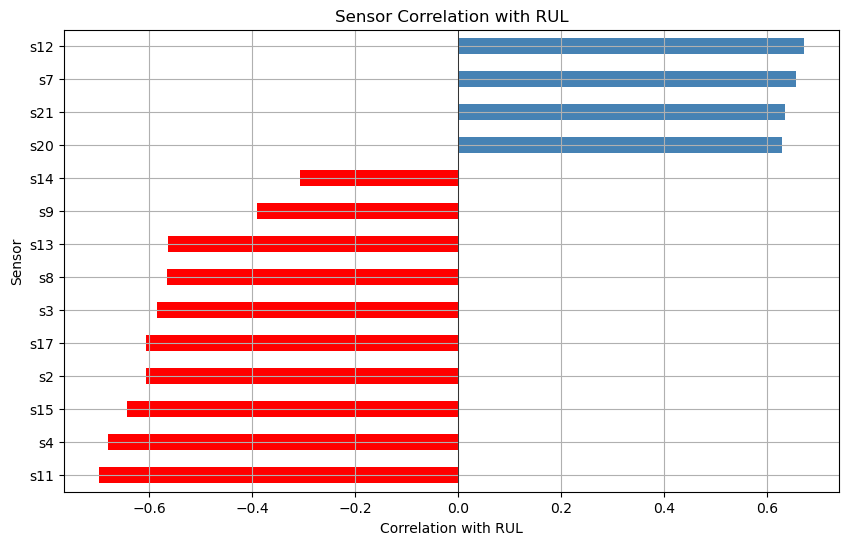


Correlation values:
s11   -0.696228
s4    -0.678948
s15   -0.642667
s2    -0.606484
s17   -0.606154
s3    -0.584520
s8    -0.563968
s13   -0.562569
s9    -0.390102
s14   -0.306769
s20    0.629428
s21    0.635662
s7     0.657223
s12    0.671983
Name: RUL, dtype: float64


In [22]:
# Calculating correlation of each sensor with RUL
# Keeping only the sensors we didn't drop
useful_sensors = [s for s in [f's{i}' for i in range(1,22)] if s not in flat_sensors]

correlations = train[useful_sensors + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

# Plot
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['red' if x < 0 else 'steelblue' for x in correlations])
plt.xlabel('Correlation with RUL')
plt.ylabel('Sensor')
plt.title('Sensor Correlation with RUL')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.grid(True)
plt.show()

print("\nCorrelation values:")
print(correlations)

In [23]:
# Dropping the flat sensors identified in EDA
flat_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
train_clean = train.drop(columns=flat_sensors)

print("Shape before:", train.shape)
print("Shape after:", train_clean.shape)
print("Remaining columns:", train_clean.columns.tolist())

Shape before: (20631, 27)
Shape after: (20631, 20)
Remaining columns: ['engine_id', 'cycle', 'op1', 'op2', 'op3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']


In [24]:
# Rolling window of 5 cycles
# For each sensor, calculating the rolling mean and std
# This gives the model a sense of recent trend

window_size = 5
sensors_to_roll = ['s2', 's3', 's4', 's7', 's8', 's9','s11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

# Group by engine so rolling doesn't bleed across different engines
for sensor in sensors_to_roll:
    train_clean[f'{sensor}_rollmean'] = train_clean.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
    
    train_clean[f'{sensor}_rollstd'] = train_clean.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window=window_size, min_periods=1).std().fillna(0))

print("Shape after rolling features:", train_clean.shape)
print("New columns added:", [c for c in train_clean.columns if 'roll' in c][:6], "...")

Shape after rolling features: (20631, 48)
New columns added: ['s2_rollmean', 's2_rollstd', 's3_rollmean', 's3_rollstd', 's4_rollmean', 's4_rollstd'] ...


In [27]:
# Columns we want to normalize (everything except engine_id, cycle and RUL)
feature_cols = [c for c in train_clean.columns if c not in ['engine_id', 'cycle', 'RUL']]

scaler = MinMaxScaler()
train_clean[feature_cols] = scaler.fit_transform(train_clean[feature_cols])

print("\nSample of normalized values:")
print(train_clean[feature_cols[:4]].describe().round(2))


Sample of normalized values:
            op1       op2      op3        s2
count  20631.00  20631.00  20631.0  20631.00
mean       0.50      0.50      0.0      0.44
std        0.13      0.24      0.0      0.15
min        0.00      0.00      0.0      0.00
25%        0.41      0.33      0.0      0.34
50%        0.50      0.50      0.0      0.43
75%        0.59      0.75      0.0      0.54
max        1.00      1.00      0.0      1.00


In [28]:
train_clean.drop(columns=['op3'], inplace=True)
print("Final shape:", train_clean.shape)

Final shape: (20631, 47)


In [29]:
train_clean.to_csv('../data/processed/train_FD001_processed.csv', index=False)
print("Saved to data/processed/")

Saved to data/processed/


In [30]:
# X = all features (everything except engine_id, cycle and RUL)
# y = what we want to predict (RUL)

X = train_clean.drop(columns=['engine_id', 'cycle', 'RUL'])
y = train_clean['RUL']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 RUL values:", y.head().values)

Features shape: (20631, 44)
Target shape: (20631,)

First 5 RUL values: [191 190 189 188 187]


In [34]:
#train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (16504, 44)
Testing set size: (4127, 44)


In [ ]:
# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("LINEAR REGRESSION RESULTS:")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE:  {lr_mae:.2f}")
print(f"R2:   {lr_r2:.4f}")

LINEAR REGRESSION RESULTS:
RMSE: 43.49
MAE:  33.36
R2:   0.5860


In [40]:
#RandomForest
# Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("RANDOM FOREST RESULTS:")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE:  {rf_mae:.2f}")
print(f"R2:   {rf_r2:.4f}")

RANDOM FOREST RESULTS:
RMSE: 34.27
MAE:  23.59
R2:   0.7429


In [43]:
#XGBoost 
# Train
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBOOST RESULTS:")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAE:  {xgb_mae:.2f}")
print(f"R2:   {xgb_r2:.4f}")

XGBOOST RESULTS:
RMSE: 36.38
MAE:  25.76
R2:   0.7103


In [44]:
# Tuned XGBoost
xgb_tuned = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_tuned.fit(X_train, y_train)

xgb_tuned_pred = xgb_tuned.predict(X_test)

xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
xgb_tuned_mae = mean_absolute_error(y_test, xgb_tuned_pred)
xgb_tuned_r2 = r2_score(y_test, xgb_tuned_pred)

print("TUNED XGBOOST RESULTS:")
print(f"RMSE: {xgb_tuned_rmse:.2f}")
print(f"MAE:  {xgb_tuned_mae:.2f}")
print(f"R2:   {xgb_tuned_r2:.4f}")

TUNED XGBOOST RESULTS:
RMSE: 37.62
MAE:  26.80
R2:   0.6902


In [45]:
from sklearn.ensemble import GradientBoostingRegressor

In [46]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("GRADIENT BOOSTING RESULTS:")
print(f"RMSE: {gb_rmse:.2f}")
print(f"MAE:  {gb_mae:.2f}")
print(f"R2:   {gb_r2:.4f}")

GRADIENT BOOSTING RESULTS:
RMSE: 37.65
MAE:  26.92
R2:   0.6897


In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

# Evaluate best model
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print(f"\nBEST RANDOM FOREST RESULTS:")
print(f"RMSE: {best_rf_rmse:.2f}")
print(f"MAE:  {best_rf_mae:.2f}")
print(f"R2:   {best_rf_r2:.4f}")



Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

BEST RANDOM FOREST RESULTS:
RMSE: 34.14
MAE:  23.54
R2:   0.7450


In [49]:
import pickle
import os

#Saving the best model
with open('../outputs/models/best_random_forest.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("Best model saved")

# Store all results in a dictionary for comparison later
results = {
    'Linear Regression': {'RMSE': lr_rmse, 'MAE': lr_mae, 'R2': lr_r2},
    'Random Forest': {'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2},
    'XGBoost': {'RMSE': xgb_rmse, 'MAE': xgb_mae, 'R2': xgb_r2},
    'XGBoost Tuned': {'RMSE': xgb_tuned_rmse, 'MAE': xgb_tuned_mae, 'R2': xgb_tuned_r2},
    'Gradient Boosting': {'RMSE': gb_rmse, 'MAE': gb_mae, 'R2': gb_r2},
    'Best Random Forest': {'RMSE': best_rf_rmse, 'MAE': best_rf_mae, 'R2': best_rf_r2}
}

print("Results stored.")

Best model saved
Results stored.


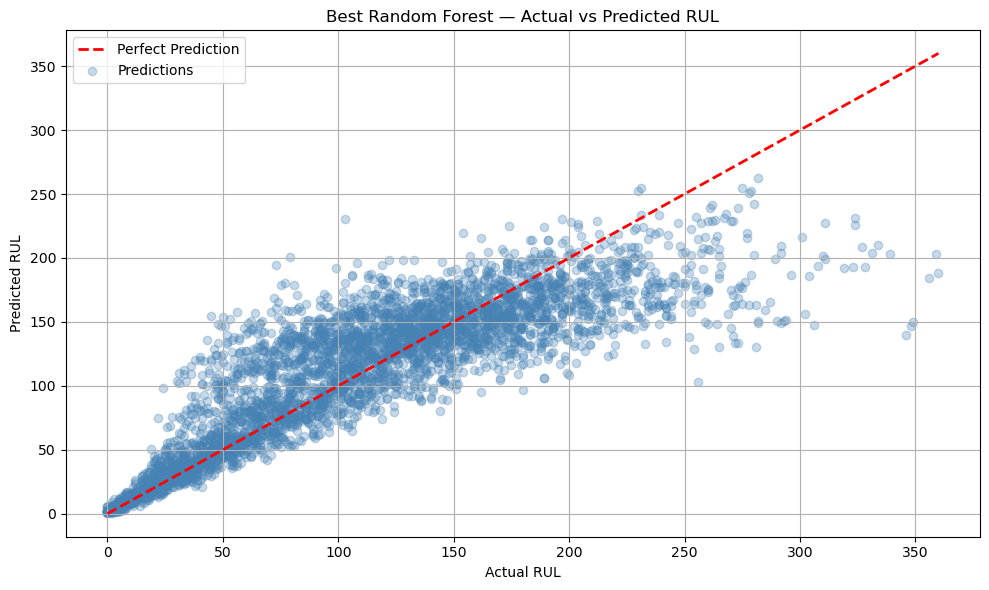

Plot saved!


In [50]:
plt.figure(figsize=(10, 6))

# Plot perfect prediction line
max_val = max(y_test.max(), best_rf_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction', linewidth=2)

# Plot actual vs predicted
plt.scatter(y_test, best_rf_pred, alpha=0.3, color='steelblue', label='Predictions')

plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Best Random Forest — Actual vs Predicted RUL')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/actual_vs_predicted.png', dpi=150)
plt.show()

print("Plot saved!")

In [52]:
# Apply RUL capping at 125
cap = 125

y_capped = y.clip(upper=cap)

# Retrain with capped RUL
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_capped, test_size=0.2, random_state=42
)

# Train best Random Forest on capped RUL
rf_capped = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf_capped.fit(X_train_c, y_train_c)

# Evaluate
rf_capped_pred = rf_capped.predict(X_test_c)

rf_capped_rmse = np.sqrt(mean_squared_error(y_test_c, rf_capped_pred))
rf_capped_mae = mean_absolute_error(y_test_c, rf_capped_pred)
rf_capped_r2 = r2_score(y_test_c, rf_capped_pred)

print("CAPPED RUL RANDOM FOREST RESULTS:")
print(f"RMSE: {rf_capped_rmse:.2f}")
print(f"MAE:  {rf_capped_mae:.2f}")
print(f"R2:   {rf_capped_r2:.4f}")

CAPPED RUL RANDOM FOREST RESULTS:
RMSE: 15.51
MAE:  10.89
R2:   0.8581


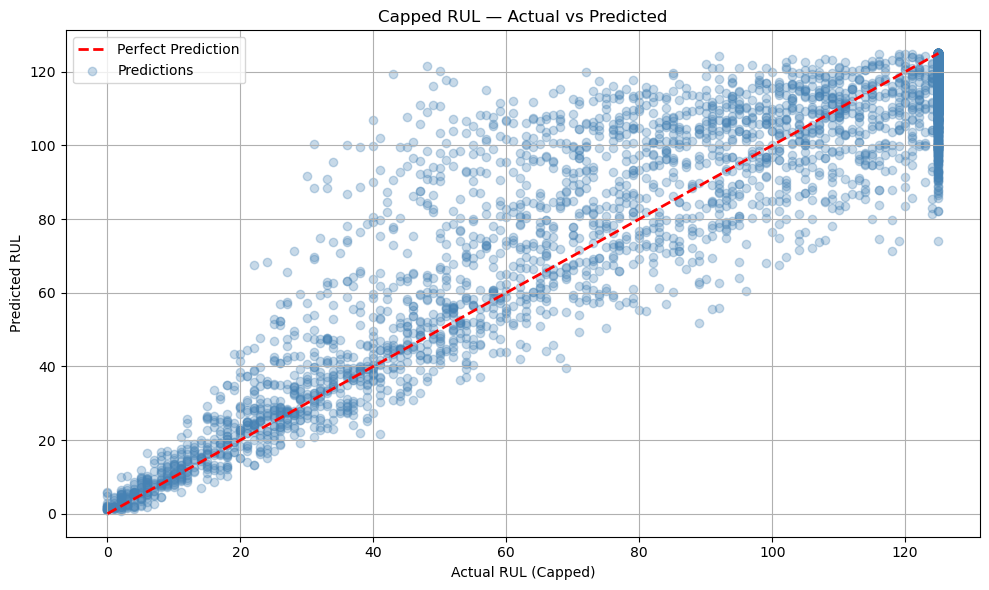

In [53]:
plt.figure(figsize=(10, 6))

max_val = max(y_test_c.max(), rf_capped_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction', linewidth=2)
plt.scatter(y_test_c, rf_capped_pred, alpha=0.3, color='steelblue', label='Predictions')

plt.xlabel('Actual RUL (Capped)')
plt.ylabel('Predicted RUL')
plt.title('Capped RUL — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/actual_vs_predicted_capped.png', dpi=150)
plt.show()

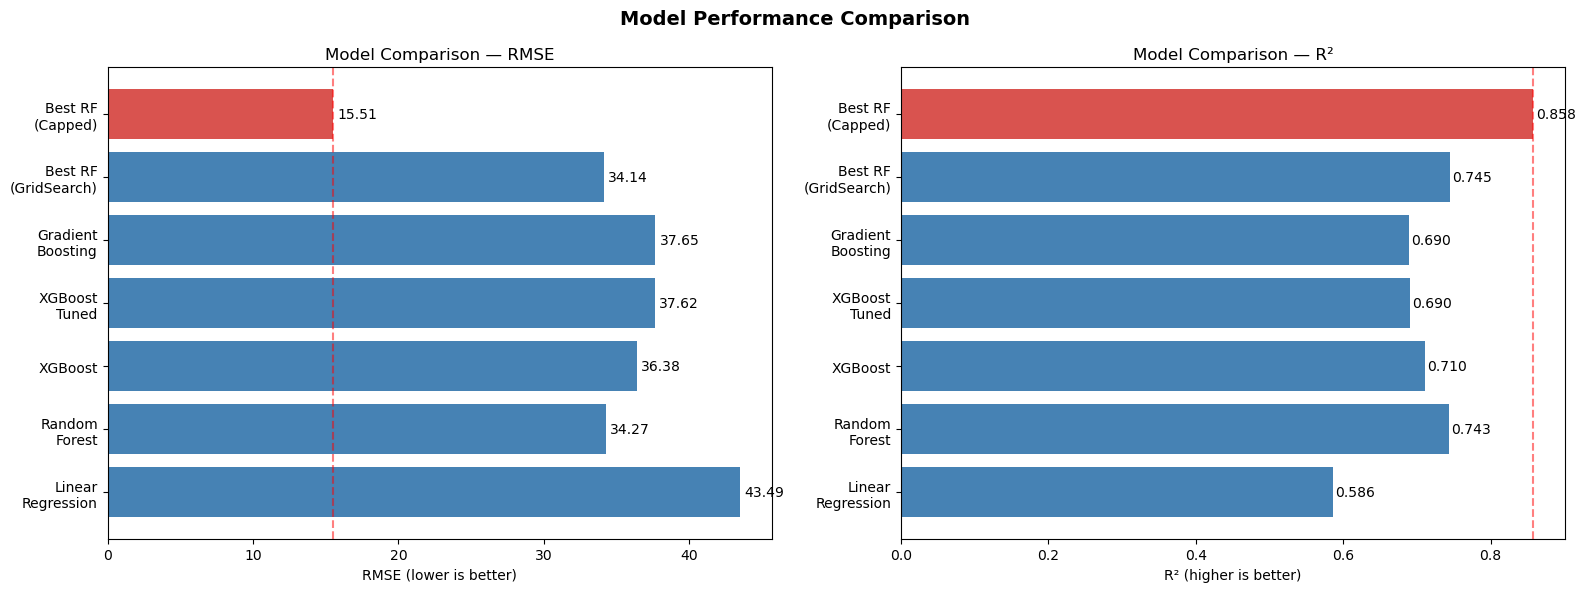

Model comparison chart saved!


In [54]:
# Model comparison visualization
models_names = ['Linear\nRegression', 'Random\nForest', 'XGBoost', 'XGBoost\nTuned', 'Gradient\nBoosting','Best RF\n(GridSearch)', 'Best RF\n(Capped)']

rmse_scores = [lr_rmse, rf_rmse, xgb_rmse, xgb_tuned_rmse,gb_rmse, best_rf_rmse, rf_capped_rmse]

r2_scores = [lr_r2, rf_r2, xgb_r2, xgb_tuned_r2,gb_r2, best_rf_r2, rf_capped_r2]

colors = ['#d9534f' if r == min(rmse_scores) else 'steelblue' for r in rmse_scores]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE comparison
axes[0].barh(models_names, rmse_scores, color=colors)
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('Model Comparison — RMSE')
axes[0].axvline(x=min(rmse_scores), color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(rmse_scores):
    axes[0].text(v + 0.3, i, f'{v:.2f}', va='center')

# R2 comparison
colors_r2 = ['#d9534f' if r == max(r2_scores) else 'steelblue' for r in r2_scores]
axes[1].barh(models_names, r2_scores, color=colors_r2)
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('Model Comparison — R²')
axes[1].axvline(x=max(r2_scores), color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(r2_scores):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150)
plt.show()

print("Model comparison chart saved!")

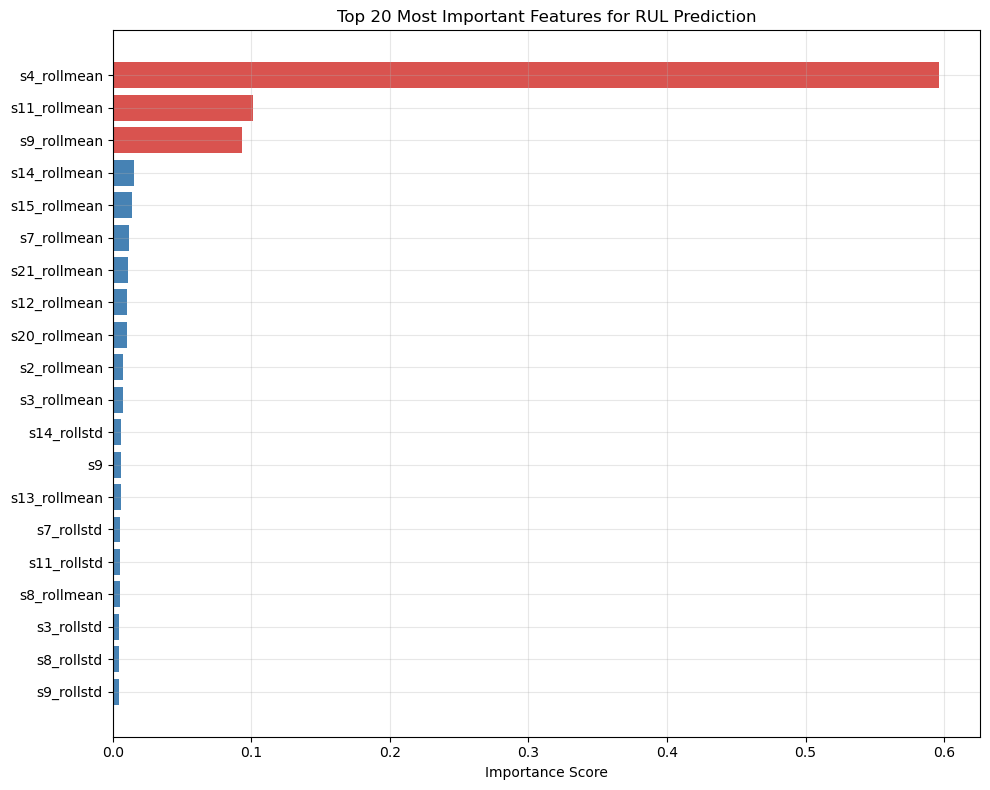

Top 10 most important features:
     feature  importance
 s4_rollmean    0.596016
s11_rollmean    0.101215
 s9_rollmean    0.093635
s14_rollmean    0.015331
s15_rollmean    0.013875
 s7_rollmean    0.011565
s21_rollmean    0.010711
s12_rollmean    0.010485
s20_rollmean    0.010077
 s2_rollmean    0.007521


In [ ]:
# to get feature importance from our best capped model
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_capped.feature_importances_
}).sort_values('importance', ascending=True)

# Plotting top 20 most important features
top_20 = feature_importance.tail(20)

plt.figure(figsize=(10, 8))
colors = ['#d9534f' if i >= 17 else 'steelblue' for i in range(len(top_20))]
plt.barh(top_20['feature'], top_20['importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features for RUL Prediction')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()

# top 10
print("Top 10 most important features:")
print(feature_importance.tail(10)[['feature', 'importance']]\
      .sort_values('importance', ascending=False).to_string(index=False))

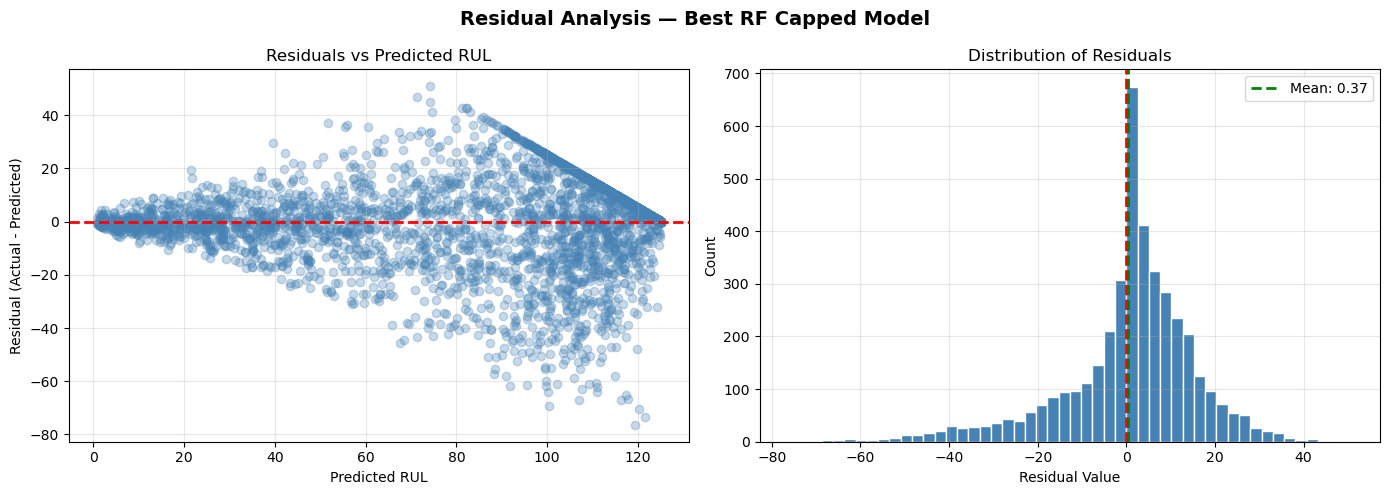

Mean residual: 0.3732
Std of residuals: 15.5105


In [56]:
# Residuals = Actual - Predicted
residuals = y_test_c - rf_capped_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Residuals vs Predicted
axes[0].scatter(rf_capped_pred, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted RUL')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted RUL')
axes[0].grid(True, alpha=0.3)

# Plot 2 — Residual Distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=residuals.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {residuals.mean():.2f}')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis — Best RF Capped Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/residual_analysis.png', dpi=150)
plt.show()

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Std of residuals: {residuals.std():.4f}")